In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import netCDF4
import numpy as np
import xarray as xr
#import pandas as pd 
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
#from cartopy.util import add_cyclic_point
from windspharm.xarray import VectorWind
mpl.rcParams['mathtext.default'] = 'regular'
#import numpy as np
import cartopy.feature as feature

In [2]:
#path_sm = '/g/data/jk72/sm3719/'
#path_cmip = 'cmip6'
#path_ds = '/pictrl/CSIRO-MK3-6-0/climate_index/eof/IOBM-IOD/eof2_CSIRO-Mk3-6-0-iobm_kave.nc'
#xr.open_dataset(path_sm + path_cmip)

In [3]:
ds1=xr.open_dataset('Regression_SST_spatial_pattern_IPO_ERSSTv5-23models.nc')
ds2=xr.open_dataset('Regression_SST_spatial_pattern_IPO_MMM.nc')

IPO1=ds1['SLOPE'][0,:,:]
IPO2=ds1['SLOPE'][1,:,:]
IPO3=ds1['SLOPE'][2,:,:]
IPO4=ds1['SLOPE'][3,:,:]
IPO5=ds1['SLOPE'][4,:,:]
IPO6=ds1['SLOPE'][5,:,:]
IPO7=ds1['SLOPE'][6,:,:]
IPO8=ds1['SLOPE'][7,:,:]
IPO9=ds1['SLOPE'][8,:,:]
IPO10=ds1['SLOPE'][9,:,:]

#weight=ds9['clat']
#wslope1=slope1*weight
#weight.shape
print(ds2.coords)
LON = ds1.LON121_281.data
LAT = ds1.LAT20_161.data
LON=np.linspace(120,280,161)
LAT=np.linspace(-70,70,142)
LON,LAT=np.meshgrid(LON,LAT)

#LON1 = ds9.LON.data
#LAT1 = ds9.LAT.data
#LON1=np.linspace(40,110,36)
#LAT1=np.linspace(-20,25,23)
#LON1,LAT1=np.meshgrid(LON1,LAT1)

Coordinates:
  * LON121_281  (LON121_281) float64 1kB 120.0 121.0 122.0 ... 278.0 279.0 280.0
  * LAT20_161   (LAT20_161) float64 1kB -70.3 -69.31 -68.31 ... 68.31 69.31 70.3


In [4]:
IPO11=ds1['SLOPE'][10,:,:]
IPO12=ds1['SLOPE'][11,:,:]
IPO13=ds1['SLOPE'][12,:,:]
IPO14=ds1['SLOPE'][13,:,:]
IPO15=ds1['SLOPE'][14,:,:]
IPO16=ds1['SLOPE'][15,:,:]
IPO17=ds1['SLOPE'][16,:,:]
IPO18=ds1['SLOPE'][17,:,:]
IPO19=ds1['SLOPE'][18,:,:]
IPO20=ds1['SLOPE'][19,:,:]
IPO21=ds1['SLOPE'][20,:,:]
IPO22=ds1['SLOPE'][21,:,:]
IPO23=ds1['SLOPE'][22,:,:]
IPO24=ds1['SLOPE'][23,:,:]
IPO25=ds2['MMM'][:,:]

In [5]:
datasets = [
    (IPO1, "(a) ERSSTv5 (EOF1-32.3%)"),
    (IPO2, "(b) CanESM5 (EOF1-27.1%)"),
    (IPO3, "(c) HadGEM3-GC31-LL (EOF3-30.9%)"),
    (IPO4, "(d) EC-Earth3-CC (EOF1-22.6%)"),
    (IPO5, "(e) CMCC-CM2-SR5 (EOF1-36.5%)"),
    (IPO6, "(f) CNRM-CM6-1 (EOF3-11.6%)"),
    (IPO7, "(g) GISS-E2-1-G (EOF2-11.1%)"),
    (IPO8, "(h) CMCC-ESM2 (EOF1-32.2%)"),
    (IPO9, "(i) EC-Earth3 (EOF2-15.7%)"),
    (IPO10, "(j) E3SM1-0 (EOF1-28.0%)"),
    (IPO11, "(k) MIROC6 (EOF1-38.7%)"),
    (IPO12, "(l) MRI-ESM2-0 (EOF1-27.3%)"),
    (IPO13, "(m) HadGEM3-GC31-MM (EOF1-25.4%)"),
    (IPO14, "(n) BCC-CSM2-MR (EOF1-27.3%)"),
    (IPO15, "(o) IPSL-CM6A-LR (EOF1-21.6%)"),
    (IPO16, "(p) MPI-ESM1-2-HR (EOF1-30.1%)"),
    (IPO17, "(q) ACCESS-ESM1-5 (EOF1-29.3%)"),
    (IPO18, "(r) ACCESS-CM2 (EOF1-20.6%)"),
    (IPO19, "(s) CESM2 (EOF1-44.6%)"),
    (IPO20, "(t) GFDL-CM4 (EOF1-24.1%)"),
    (IPO21, "(u) CIESM (EOF1-27.6%)"),
    (IPO22, "(v) FGOALS-g3 (EOF1-17.8%)"),
    (IPO23, "(w) SAM0-UNICON (EOF1-32.3%)"),
    (IPO24, "(x) CNRM-ESM2-1 (EOF2-14.0%)"),
    (IPO25, "(y) MMM")
]

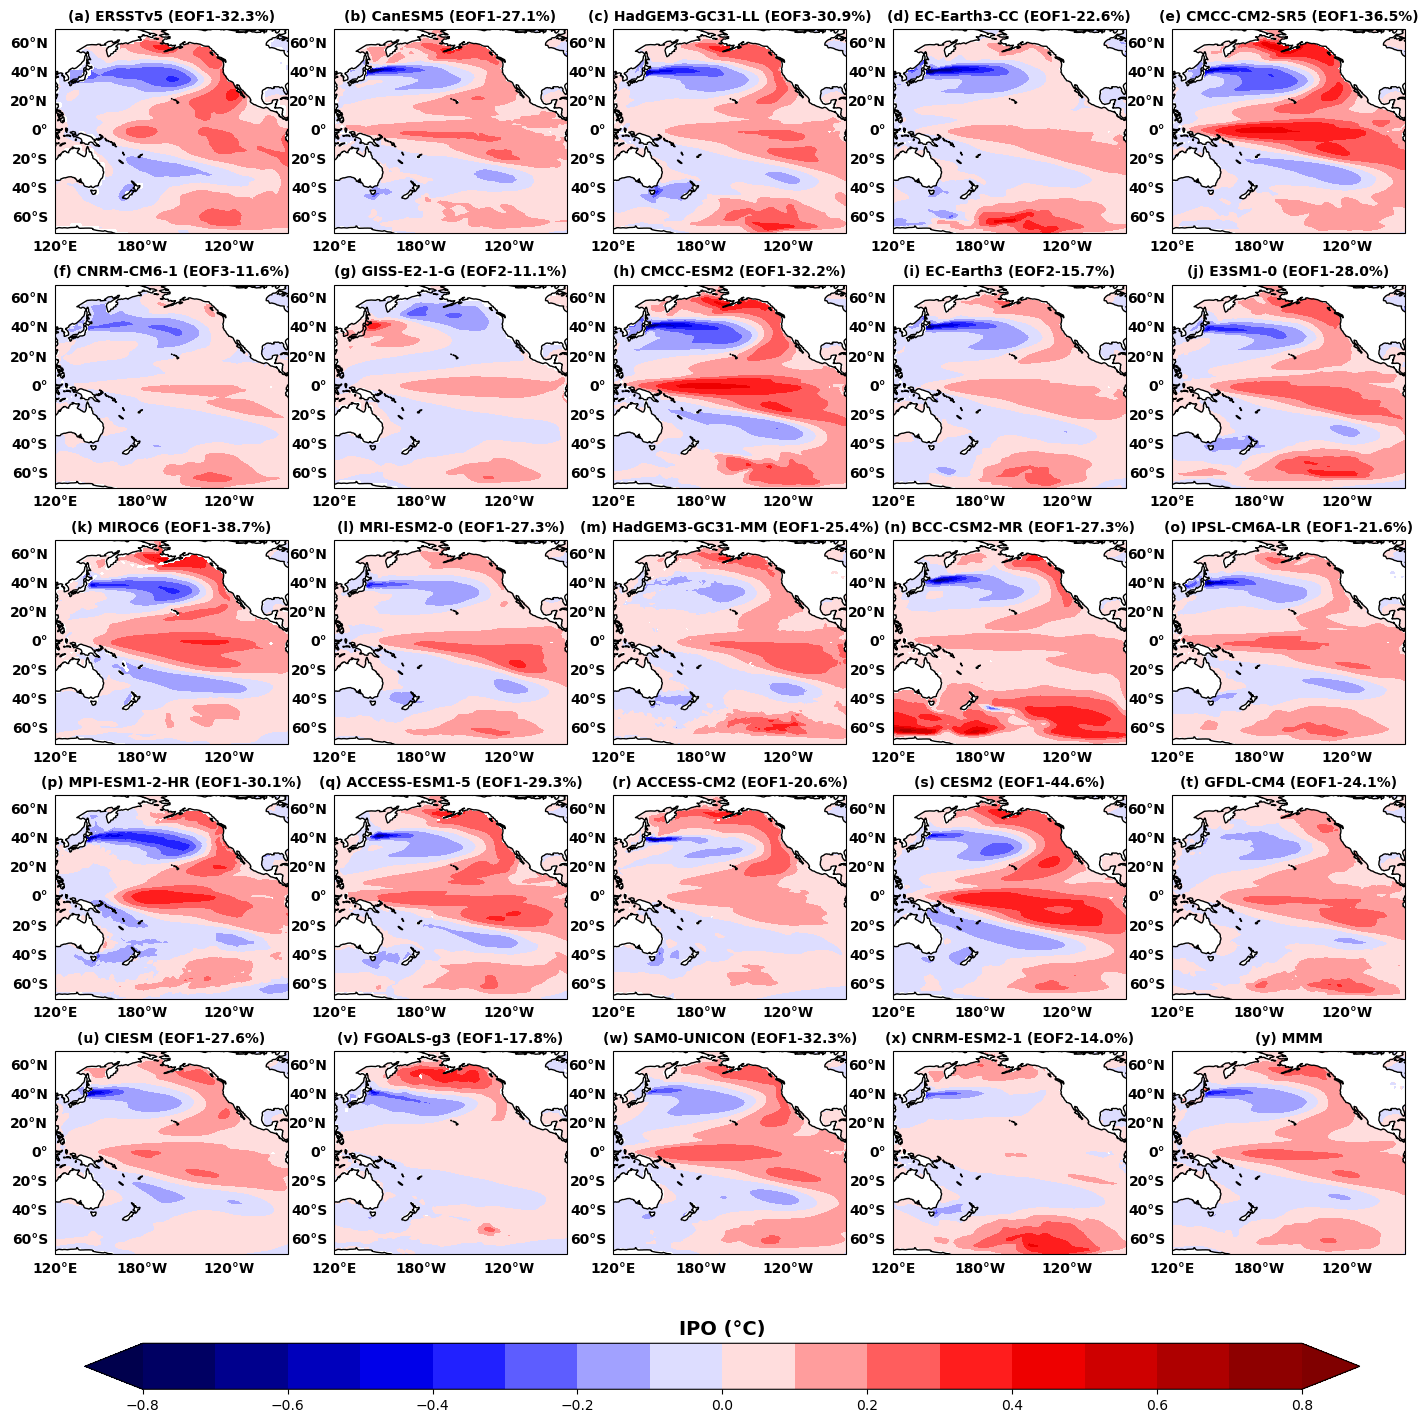

In [7]:
# Subplot configuration
nrows, ncols = 5, 5
start_index = 1  # Starting index for subplots
projection = ccrs.PlateCarree(central_longitude=260)
clevs = np.arange(-0.8, 0.9, 0.1)

# Create figure
fig = plt.figure(figsize=(15, 23))
# Store the last `contourf` plot for the colorbar
last_fill_sf = None

for i, (data, title) in enumerate(datasets, start=start_index):
    ax = plt.subplot(nrows, ncols, i, projection=projection)
    fill_sf = ax.contourf(
        LON, LAT, data, levels=clevs, cmap=plt.cm.seismic, 
        transform=ccrs.PlateCarree(), extend='both'
    )
    last_fill_sf = fill_sf  # Update the last contourf object
    ax.set_aspect('equal')
    ax.coastlines()
    ax.set_title(title, fontsize=10, loc='center', color='black', fontweight='bold')
#    ax.annotate(annotation, xy=(0.5, -0.11), xycoords='axes fraction', ha='center', va='top', fontsize=10, color='red', fontweight='bold')
    # Gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
# --- Longitude labels ---
    gl.top_labels = False       # no longitude labels on top
    gl.bottom_labels = True     # show longitude labels only on the bottom
# --- Latitude labels ---
    gl.left_labels = True       # keep latitude labels on the left
    gl.right_labels = False     # no latitude labels on the right
# --- Gridline drawing ---
    gl.xlines = False           # don't draw the longitude gridlines themselves
    gl.ylines = False           # don't draw the latitude gridlines themselves
# --- Formatters ---
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'weight': 'bold'}
    gl.ylabel_style = {'size': 10, 'weight': 'bold'}

# Adjust layout (moved outside the `if` block)
plt.subplots_adjust(bottom=0.4, left=0.08, right=0.98, top=0.95, hspace=0.05)

# Add colorbar
if last_fill_sf is not None:  # Check if a valid contourf object exists
    cax = plt.axes([0.1, 0.35, 0.85, 0.02])  # Adjust these values for proper placement
    clb = plt.colorbar(last_fill_sf, cax=cax, orientation='horizontal', fraction=0.1, pad=0.05)
    clb.ax.set_title('IPO (°C)', loc='center', color='black', fontsize=14, fontweight='bold')

# Save and show plot
plt.savefig('panel25_regression_IPO_models_observations_mmm.png', dpi=600)
plt.show()

In [36]:
print(last_fill_sf)

None


# 

##### 